# Recommendation Performance over Time

This notebook computes and plots the rating prediction and ranking metrics (**RMSE, NDCG@10, and MAP@10**) across sequential temporal folds.

It compares:
1. **Non-Wasserstein models** (first row of plots: models without `_wasserstein` in their names).
2. **Wasserstein-regularized models** with intensity 1 (second row of plots: models ending in `_wasserstein` or `_wasserstein-1` with intensity 1).

The metrics are parsed directly from the `metrics-*.json` files generated for each fold.

In [6]:
import os
import glob
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

## Load Metrics JSON Files

We search all folders in the `runs` directory, parsing folders for dataset, model, fold, and Wasserstein regularization settings. We load the main `metrics-{fold}.json` files and extract `rmse`, `mNDCG@10`, and `MAP@10` from the `eval` section.

In [7]:
# Resolve directory path
if os.path.exists("runs"):
    runs_dir = "runs"
elif os.path.exists("../runs"):
    runs_dir = "../runs"
else:
    runs_dir = "runs"

datasets_list = ["amazon-beauty", "amazon-movies-tvs", "ml-1m", "netflix-prize"]
pattern_was = re.compile(r"^([a-zA-Z0-9]+)_wasserstein(?:-([0-9.]+))?-([0-9]+)$")
pattern_non = re.compile(r"^([a-zA-Z0-9]+)-([0-9]+)$")
pattern_metric_file = re.compile(r"^metrics-(\d+)(?:-(.+))?\.json$")

data_points = []

for folder in os.listdir(runs_dir):
    path = os.path.join(runs_dir, folder)
    if not os.path.isdir(path):
        continue
    
    # Scan for metrics-*.json files (taking the latest version if multiple exist)
    fold_files = {}
    for f in os.listdir(path):
        m = pattern_metric_file.match(f)
        if m:
            fold = int(m.group(1))
            timestamp = m.group(2) or ""
            if fold not in fold_files:
                fold_files[fold] = []
            fold_files[fold].append((os.path.join(path, f), timestamp))
            
    metric_files = []
    for fold, files in fold_files.items():
        files.sort(key=lambda x: x[1])
        latest_file_path, _ = files[-1]
        metric_files.append((latest_file_path, fold))
            
    if not metric_files:
        continue
        
    db = None
    for d in datasets_list:
        if folder.startswith(d + "-"):
            db = d
            break
    if not db:
        continue
        
    rem = folder[len(db)+1:]
    
    # Match Wasserstein runs
    m_was = pattern_was.match(rem)
    if m_was:
        model, intensity, fold = m_was.groups()
        intensity = float(intensity) if intensity is not None else 1.0
        fold = int(fold)
        is_was = True
    else:
        # Match non-Wasserstein runs
        m_non = pattern_non.match(rem)
        if m_non:
            model, fold = m_non.groups()
            intensity = 0.0
            fold = int(fold)
            is_was = False
        else:
            continue
            
    for metric_path, file_fold in metric_files:
        try:
            with open(metric_path, "r") as f:
                content = json.load(f)
            eval_metrics = content.get("eval", {})
            rmse = float(eval_metrics.get("rmse", np.nan))
            ndcg = float(eval_metrics.get("mNDCG@10", np.nan))
            map_val = float(eval_metrics.get("MAP@10", np.nan))
            
            data_points.append({
                "dataset": db,
                "model": model,
                "is_wasserstein": is_was,
                "intensity": intensity,
                "fold": file_fold,
                "rmse": rmse,
                "ndcg": ndcg,
                "map": map_val
            })
        except Exception as e:
            print(f"Error reading {metric_path}: {e}")

df_results = pd.DataFrame(data_points)

# Filter to keep only Wasserstein intensity 1.0 or non-Wasserstein runs
df_filtered = df_results[
    (df_results.is_wasserstein == False) | (df_results.intensity == 1.0)
]

print(f"Loaded {len(df_filtered)} metrics points.")
df_filtered.head()

Loaded 85 metrics points.


,dataset,model,is_wasserstein,intensity,fold,rmse,ndcg,map
0,ml-1m,mf,True,1.0,3,1.105854,0.45101,0.31228
1,ml-1m,cpmf,False,0.0,2,1.106968,0.65751,0.15006
2,ml-1m,dropout,False,0.0,5,0.938241,0.60833,0.58813
3,netflix-prize,dropout,False,0.0,0,1.016096,0.60713,0.55655
5,ml-1m,lbd,True,1.0,2,0.988692,0.65939,0.14963


## Define Reusable Plotting Function
We encapsulate the plotting logic inside `plot_performance_over_time`, which accepts lists of `models`, `datasets`, and `metrics` to customize the visualization output dynamically.

In [11]:
def plot_performance_over_time(df, models=None, datasets=None, metrics=None, prefix=""):
    """
    Plots recommendation performance metrics over folds for specified models, datasets, and metrics.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing the metrics data.
        models (list of str, optional): Models to include. If None, plots all models that have both 
                                       Wasserstein and non-Wasserstein runs for each dataset.
        datasets (list of str, optional): Datasets to include. If None, plots all datasets in df.
        metrics (list of str, optional): Metrics to plot. Options: 'rmse', 'ndcg', 'map'. 
                                        Defaults to all three.
    """
    if datasets is None:
        datasets = sorted(df["dataset"].unique())
        
    if metrics is None:
        metrics = ["rmse", "ndcg", "map"]
        
    # Default metric configurations for plotting
    metric_configs = {
        "rmse": {"label": "RMSE", "color": "#d62728", "marker": "o"},
        "ndcg": {"label": "NDCG@10", "color": "#2ca02c", "marker": "s"},
        "map": {"label": "MAP@10", "color": "#1f77b4", "marker": "^"}
    }
    
    os.makedirs("plots", exist_ok=True)
    
    for db in datasets:
        df_db = df[df["dataset"] == db]
        if df_db.empty:
            print(f"No data for dataset {db}.")
            continue
            
        # Determine models to plot for this dataset
        if models is None:
            # Only keep models that have both Wasserstein (intensity 1) and non-Wasserstein runs
            valid_models = []
            for m in df_db["model"].unique():
                has_non = not df_db[(df_db["model"] == m) & (df_db["is_wasserstein"] == False)].empty
                has_was = not df_db[(df_db["model"] == m) & (df_db["is_wasserstein"] == True)].empty
                if has_non and has_was:
                    valid_models.append(m)
            db_models = sorted(valid_models)
        else:
            db_models = [m for m in models if m in df_db["model"].unique()]
            
        num_models = len(db_models)
        if num_models == 0:
            print(f"No models to plot for dataset {db}.")
            continue
            
        fig, axes = plt.subplots(2, num_models, figsize=(5 * num_models, 7), sharex=False, squeeze=False)
        
        for col_idx, model in enumerate(db_models):
            for row_idx, is_was in enumerate([False, True]):
                ax = axes[row_idx, col_idx]
                
                df_sub = df_db[(df_db["model"] == model) & (df_db["is_wasserstein"] == is_was)]
                df_sub = df_sub.sort_values("fold")
                
                if df_sub.empty:
                    ax.text(0.5, 0.5, "No Data", ha="center", va="center", transform=ax.transAxes, color="gray")
                    ax.set_title(f"{model} " + ("(Wasserstein)" if is_was else "(No Wasserstein)"), fontsize=12)
                    continue
                    
                folds = df_sub["fold"].values
                
                # Plot each requested metric
                has_plotted_metric = False
                for met in metrics:
                    if met in df_sub.columns and not df_sub[met].isna().all():
                        vals = df_sub[met].values
                        cfg = metric_configs.get(met, {"label": met.upper(), "color": None, "marker": "x"})
                        ax.plot(folds, vals, color=cfg["color"], marker=cfg["marker"], label=cfg["label"], linewidth=2)
                        has_plotted_metric = True
                
                if not has_plotted_metric:
                    ax.text(0.5, 0.5, "No Metric Data", ha="center", va="center", transform=ax.transAxes, color="gray")
                    ax.set_title(f"{model} " + ("(Wasserstein)" if is_was else "(No Wasserstein)"), fontsize=12)
                    continue
                
                # Titles and labels
                ax.set_title(f"{model} " + ("(Wasserstein)" if is_was else "(No Wasserstein)"), fontsize=12, fontweight="bold")
                ax.set_xlabel("Fold", fontsize=10)
                ax.set_xticks(folds)
                ax.set_ylabel("Metric Value", fontsize=10)
                
                # Grid and Legend
                ax.grid(True, linestyle=":", alpha=0.6)
                ax.legend(loc="best", fontsize=8)
                
        #plt.suptitle(f"Recommendation Performance per Time (Fold) - {db}", fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.savefig(f"plots/{prefix}-performance_time_{db}.png", dpi=300, bbox_inches="tight")
        plt.show()

## Generate and Save Performance Plots
Run the plotting function on all loaded runs, keeping the defaults to generate charts for all datasets, models, and performance metrics.

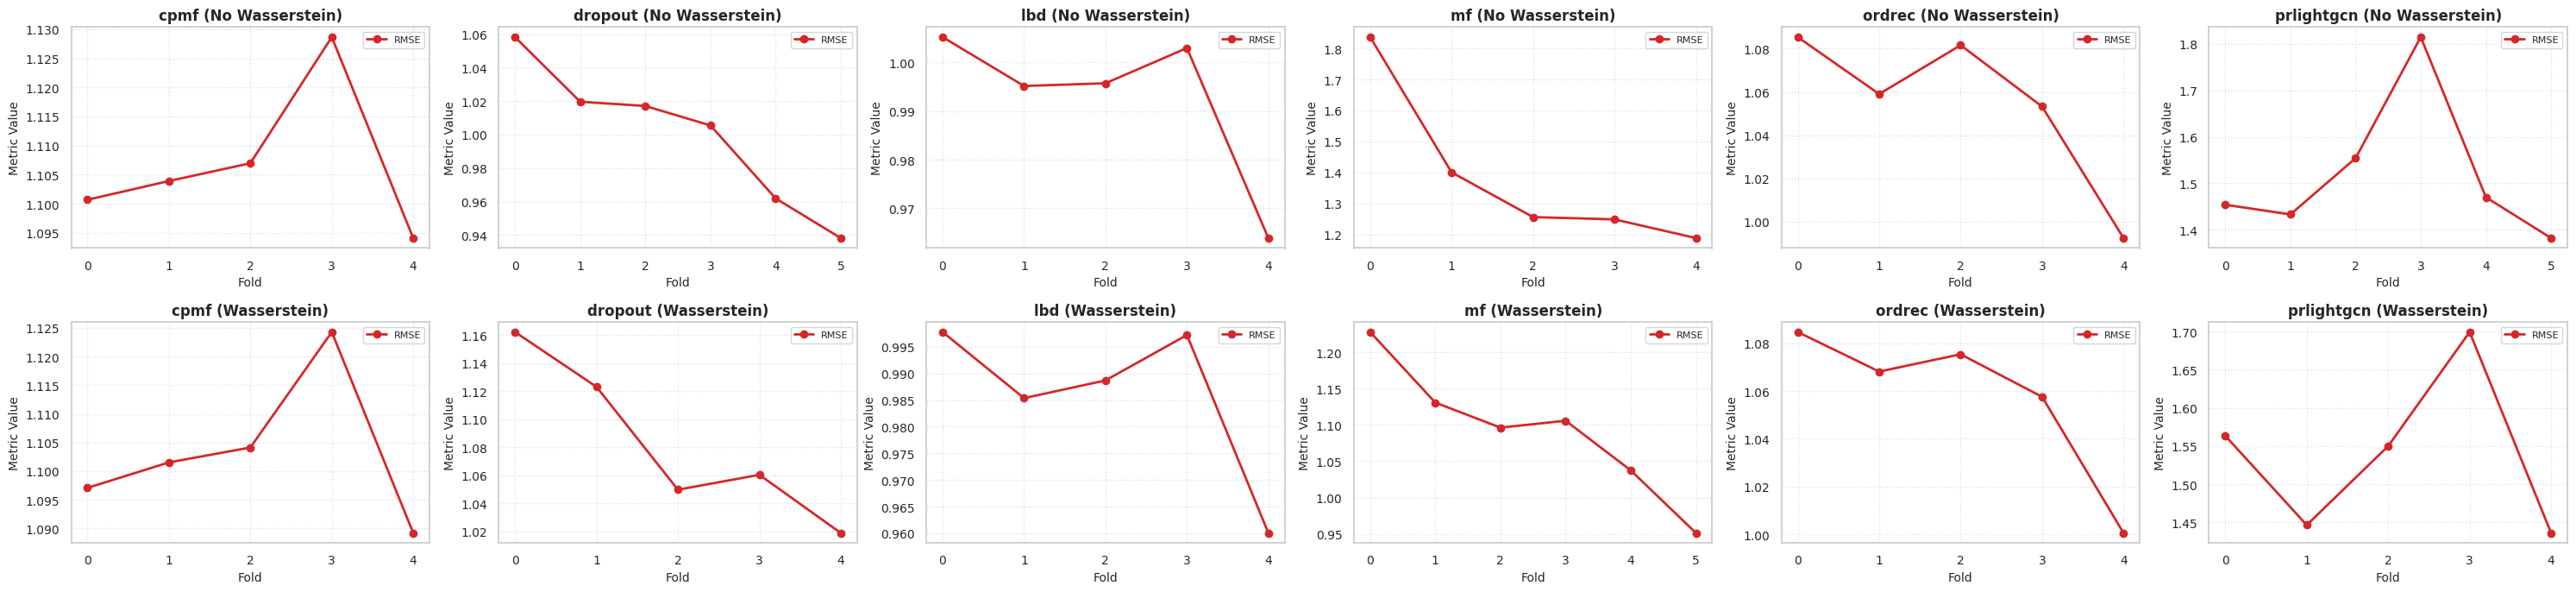

In [12]:
plot_performance_over_time(df_filtered, metrics=['rmse'], datasets=['ml-1m'], prefix="rmse")

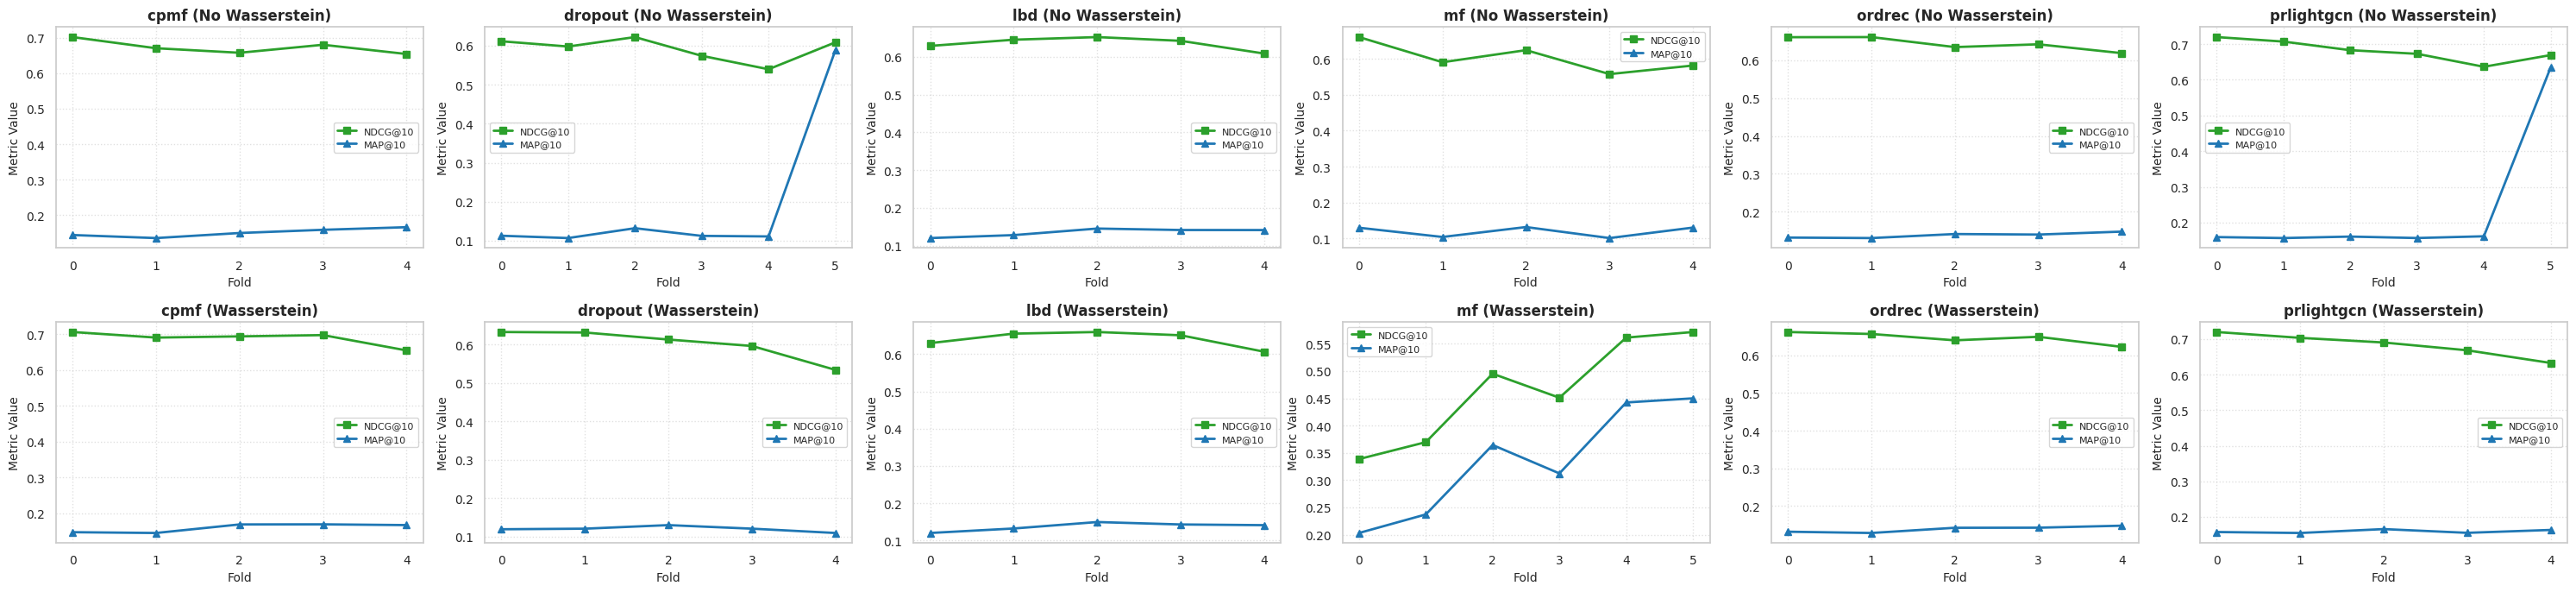

In [13]:
plot_performance_over_time(df_filtered, metrics=['ndcg','map'], datasets=['ml-1m'], prefix="ranking")